In [1]:
import numpy as np

In [7]:
array = np.arange(1,7)
array

array([1, 2, 3, 4, 5, 6])

In [23]:
a_array = array[0:7:2]
a_array

array([1, 3, 5])

In [25]:
b_array = array[1:7:2]
b_array

array([2, 4, 6])

In [29]:
array_2d = np.array([[-3,-2,-1,0,1,2,3]])
array_2d

array([[-3, -2, -1,  0,  1,  2,  3]])

In [31]:
array_2d[:,4:]

array([[1, 2, 3]])

In [33]:
array_2d[:,3:]

array([[0, 1, 2, 3]])

In [35]:
array_2d[:,:5]

array([[-3, -2, -1,  0,  1]])

In [37]:
array_2d[:,:-1]

array([[-3, -2, -1,  0,  1,  2]])

In [45]:
array_1d = np.array([1,2,3,4,5,6])
array_1d.T#一维数组转置还是一维

array([1, 2, 3, 4, 5, 6])

In [49]:
array_2d_2 = np.array([[-3,-2,-1,0,1,2,3]])
array_2d_2.T #2d数组转置

array([[-3],
       [-2],
       [-1],
       [ 0],
       [ 1],
       [ 2],
       [ 3]])

In [53]:
np.linspace(-3,3,101)

array([-3.  , -2.94, -2.88, -2.82, -2.76, -2.7 , -2.64, -2.58, -2.52,
       -2.46, -2.4 , -2.34, -2.28, -2.22, -2.16, -2.1 , -2.04, -1.98,
       -1.92, -1.86, -1.8 , -1.74, -1.68, -1.62, -1.56, -1.5 , -1.44,
       -1.38, -1.32, -1.26, -1.2 , -1.14, -1.08, -1.02, -0.96, -0.9 ,
       -0.84, -0.78, -0.72, -0.66, -0.6 , -0.54, -0.48, -0.42, -0.36,
       -0.3 , -0.24, -0.18, -0.12, -0.06,  0.  ,  0.06,  0.12,  0.18,
        0.24,  0.3 ,  0.36,  0.42,  0.48,  0.54,  0.6 ,  0.66,  0.72,
        0.78,  0.84,  0.9 ,  0.96,  1.02,  1.08,  1.14,  1.2 ,  1.26,
        1.32,  1.38,  1.44,  1.5 ,  1.56,  1.62,  1.68,  1.74,  1.8 ,
        1.86,  1.92,  1.98,  2.04,  2.1 ,  2.16,  2.22,  2.28,  2.34,
        2.4 ,  2.46,  2.52,  2.58,  2.64,  2.7 ,  2.76,  2.82,  2.88,
        2.94,  3.  ])

In [57]:
np.zeros(3)

array([0., 0., 0.])

In [63]:
np.ones([3,3])

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [79]:
np.random.rand(10) #[0,1)以内的随机数rand是random的简写,底层等于random_sample(size=...)

array([0.23102906, 0.54350449, 0.73170111, 0.89617863, 0.07691687,
       0.29239177, 0.39217942, 0.14764888, 0.70922989, 0.22703531])

In [ ]:
#学习绘制水流图

In [174]:
import matplotlib.pyplot as plt
import numpy as np

In [176]:
w = 3
Y,X = np.mgrid[-w:w:100j,-w:w:100j] #生成YX都是100*100的坐标矩阵 j利用python中虚数单位,让程序知道按照100个等距点划分
U = -1 - X**2 +Y #定义想来那个在X方向的分量
V = 1+X-Y**2 #定义向量在Y方向上的分量
speed = np.sqrt(U**2 + V**2) #计算速度大小

3

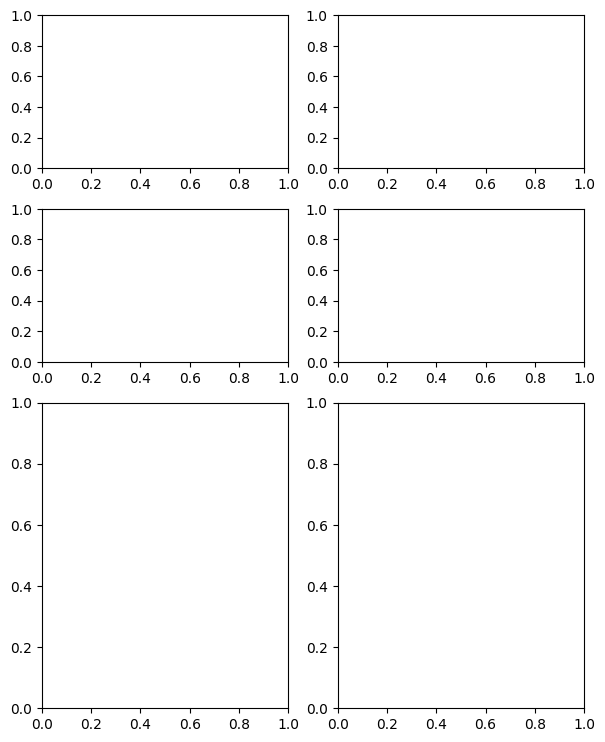

In [198]:
fig,axs = plt.subplots(3,2,
                       figsize = (7,9),
                       height_ratios = [1,1,2])#配置第三行的高度是前两行的两倍
axs = axs.flat #将axs展平为一维数组

In [196]:

#1.变化流水线密度
#
axs[0].streamplot(X,Y,U,V,density = [0.5,1]) #第一个子图上的流线图,x,y方向的密度分别为0.5,1
axs[0].set_title('Varying Density')

Text(0.5, 1.0, 'Varying Density')

In [180]:
#2.变换流线颜色
strm = axs[1].streamplot(
    X,Y,U,V,
    color = U, #按照U的分量映射颜色
    linewidth = 2,
    cmap = 'autumn')#选择配色方案
#
fig.colorbar(strm.lines)#为流线添加颜色条
axs[1].set_title('Varying Color') #设置子图坐标

Text(0.5, 1.0, 'Varying Color')

In [182]:
#3.变化流线宽度
lw = 5*speed/speed.max() #根据speed归一化后乘以5 得到每条线的宽度
axs[2].streamplot(
    X,Y,U,V,
    density = 0.6, #配置总体密度
    color = 'k',
    linewidth = lw #使用计算好的宽度lw
)
axs[2].set_title('Varying Line Width')

Text(0.5, 1.0, 'Varying Line Width')

In [184]:
#4.指定流线起点
seed_points = np.array([
    [-2,-1,0,1,2,-1],
    [-1,-1,0,1,2, 2],
]) #若干起点坐标

strm = axs[3].streamplot(
    X,Y,U,V,
    color = U,
    linewidth = 2,
    cmap = 'autumn',
    start_points = seed_points.T #指定从这些点开始
)
fig.colorbar(strm.lines)#添加颜色条
axs[3].set_title('Controlling Starting Points')

#显示起点
axs[3].plot(seed_points[0],seed_points[1],'bo')#蓝色点标记起点
axs[3].set(xlim = (-w,w),ylim = (-w,w))

[(-3.0, 3.0), (-3.0, 3.0)]

In [186]:
#5.屏蔽与NaN区域
mask = np.zeros(U.shape,dtype = bool) #创建与U形状相同的布尔掩码,初始权威False也就是0
mask[40:60,40:60] = True #将中间的一块设为True也就是1
U[:20,:20] = np.nan #左上角20*20区域配置成NaN
U = np.ma.array(U,mask = mask) #用掩码和NaN构造一个Maskedarray

axs[4].streamplot(X,Y,U,V,color = 'r') #用红色绘制流线
axs[4].set_title('Streamplot with Masking')
#用灰度图叠加掩码区域可视化
axs[4].imshow(
    ~mask, #取反掩码,是非屏蔽区显示
    extent=(-w,w,-w,w), #指定图像坐标范围
    alpha = 0.5,
    cmap = 'gray',
    aspect = 'auto'
)
axs[4].set_aspect('equal')

In [188]:
#6.不断线的流线
axs[5].streamplot(
    X,Y,U,V,
    broken_streamlines = False #禁止断线处理
)
axs[5].set_title('Streamplot with unbroken streamlines')

Text(0.5, 1.0, 'Streamplot with unbroken streamlines')

In [190]:
plt.tight_layout()#紧凑布局
plt.show() #显示所有图形

<Figure size 640x480 with 0 Axes>